In [ ]:
# =============================================================================
# EXTENDED MONTE CARLO SIMULATION
# Model-selection agreement before and after sparsification
#
# Required packages:
#   MASS
#   lars
#   glmnet
#
# No external dataset is required.
# =============================================================================


# =============================================================================
# CELL 1 — SETUP
# =============================================================================

options(stringsAsFactors = FALSE)

required_packages <- c(
  "MASS",
  "lars",
  "glmnet"
)

missing_packages <- required_packages[
  !vapply(
    required_packages,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]

if (length(missing_packages) > 0L) {
  stop(
    paste0(
      "Missing packages: ",
      paste(missing_packages, collapse = ", "),
      ". Install them in a fresh R session before running this notebook."
    )
  )
}

suppressPackageStartupMessages({
  library(MASS)
  library(lars)
  library(glmnet)
})

cat("Required packages loaded successfully.\n")

# ---------------------------------------------------------------------------
# Run controls
# ---------------------------------------------------------------------------

RUN_MONTE_CARLO <- TRUE

RUN_MODE <- "full"
RUN_SMOKE_TEST <- FALSE
RUN_MONTE_CARLO <- TRUE
# TRUE will ignore and replace existing checkpoints.
OVERWRITE_CHECKPOINTS <- FALSE

BASE_SEED <- 20260711L
SIGNAL_TO_NOISE_RATIO <- 3
TEST_SAMPLE_SIZE <- 500L
GLMNET_NLAMBDA <- 100L
COEFFICIENT_TOLERANCE <- 1e-8
CHECKPOINT_EVERY <- 5L

if (RUN_MODE == "full") {

  NUMBER_OF_REPLICATIONS <- 100L

  NP_SETTINGS <- data.frame(
    n = c(100L, 100L, 100L, 500L),
    p = c(20L, 100L, 200L, 100L)
  )

  CORRELATION_SETTINGS <- c(
    "independent",
    "ar1_rho_0.5",
    "ar1_rho_0.9",
    "block"
  )

  SPARSIFICATION_SCHEMES <- c(
    "quantile_2",
    "quantile_4",
    "quantile_8",
    "equal_width_4"
  )

} else {

  NUMBER_OF_REPLICATIONS <- 2L

  NP_SETTINGS <- data.frame(
    n = c(100L, 100L),
    p = c(20L, 100L)
  )

  CORRELATION_SETTINGS <- c(
    "independent",
    "ar1_rho_0.5"
  )

  SPARSIFICATION_SCHEMES <- c(
    "quantile_2",
    "quantile_4"
  )
}

dir.create(
  "outputs",
  showWarnings = FALSE
)

OUTPUT_DIRECTORY <- file.path(
  "outputs",
  "extended_monte_carlo"
)

dir.create(
  OUTPUT_DIRECTORY,
  recursive = TRUE,
  showWarnings = FALSE
)

CHECKPOINT_DIRECTORY <- file.path(
  OUTPUT_DIRECTORY,
  paste0("checkpoints_base_v1_", RUN_MODE)
)

dir.create(
  CHECKPOINT_DIRECTORY,
  recursive = TRUE,
  showWarnings = FALSE
)

OUTPUT_PREFIX <- if (RUN_MODE == "full") {
  ""
} else {
  "quick_"
}

output_path <- function(filename) {
  file.path(
    OUTPUT_DIRECTORY,
    paste0(OUTPUT_PREFIX, filename)
  )
}

cat("Run mode:", RUN_MODE, "\n")
cat("Replications:", NUMBER_OF_REPLICATIONS, "\n")
cat("Output folder:", normalizePath(OUTPUT_DIRECTORY), "\n")


# =============================================================================
# CELL 2 — SIMULATION DESIGN AND DATA GENERATION
# =============================================================================

design_list <- list()
design_counter <- 0L

for (np_index in seq_len(nrow(NP_SETTINGS))) {

  for (correlation_name in CORRELATION_SETTINGS) {

    design_counter <- design_counter + 1L

    current_n <- NP_SETTINGS$n[np_index]
    current_p <- NP_SETTINGS$p[np_index]

    design_list[[design_counter]] <- data.frame(
      n = current_n,
      p = current_p,
      dimension = paste0(
        "n=",
        current_n,
        ", p=",
        current_p
      ),
      correlation = correlation_name,
      active_s = max(
        5L,
        floor(0.10 * current_p)
      ),
      stringsAsFactors = FALSE
    )
  }
}

simulation_design <- do.call(
  rbind,
  design_list
)

simulation_design$scenario_id <- seq_len(
  nrow(simulation_design)
)

simulation_design <- simulation_design[
  ,
  c(
    "scenario_id",
    "n",
    "p",
    "dimension",
    "correlation",
    "active_s"
  )
]

rownames(simulation_design) <- NULL

write.csv(
  simulation_design,
  output_path("simulation_design.csv"),
  row.names = FALSE
)

print(simulation_design)


make_covariance_matrix <- function(
    p,
    correlation_structure) {

  p <- as.integer(p)

  if (correlation_structure == "independent") {

    covariance_matrix <- diag(p)

  } else if (correlation_structure == "ar1_rho_0.5") {

    feature_index <- seq_len(p)

    covariance_matrix <- 0.5^abs(
      outer(
        feature_index,
        feature_index,
        "-"
      )
    )

  } else if (correlation_structure == "ar1_rho_0.9") {

    feature_index <- seq_len(p)

    covariance_matrix <- 0.9^abs(
      outer(
        feature_index,
        feature_index,
        "-"
      )
    )

  } else if (correlation_structure == "block") {

    block_size <- 10L
    within_block_correlation <- 0.8
    between_block_correlation <- 0.1

    covariance_matrix <- matrix(
      between_block_correlation,
      nrow = p,
      ncol = p
    )

    block_starts <- seq.int(
      from = 1L,
      to = p,
      by = block_size
    )

    for (block_start in block_starts) {

      block_end <- min(
        block_start + block_size - 1L,
        p
      )

      block_indices <- block_start:block_end

      covariance_matrix[
        block_indices,
        block_indices
      ] <- within_block_correlation
    }

    diag(covariance_matrix) <- 1

  } else {

    stop(
      "Unknown correlation structure: ",
      correlation_structure
    )
  }

  minimum_eigenvalue <- min(
    eigen(
      covariance_matrix,
      symmetric = TRUE,
      only.values = TRUE
    )$values
  )

  if (minimum_eigenvalue <= 1e-8) {

    covariance_matrix <- covariance_matrix +
      diag(
        abs(minimum_eigenvalue) + 1e-6,
        p
      )
  }

  covariance_matrix
}


generate_regression_data <- function(
    n,
    p,
    correlation,
    signal_to_noise_ratio = 3,
    test_sample_size = 500L,
    seed = 1L) {

  set.seed(seed)

  covariance_matrix <- make_covariance_matrix(
    p = p,
    correlation_structure = correlation
  )

  active_s <- max(
    5L,
    floor(0.10 * p)
  )

  true_support <- sort(
    sample.int(
      p,
      size = active_s,
      replace = FALSE
    )
  )

  beta <- numeric(p)

  beta[true_support] <- sample(
    c(-1, 1),
    size = active_s,
    replace = TRUE
  ) * runif(
    active_s,
    min = 0.5,
    max = 1.5
  )

  X_train <- MASS::mvrnorm(
    n = n,
    mu = rep(0, p),
    Sigma = covariance_matrix
  )

  X_test <- MASS::mvrnorm(
    n = test_sample_size,
    mu = rep(0, p),
    Sigma = covariance_matrix
  )

  training_signal <- drop(
    X_train %*% beta
  )

  test_signal <- drop(
    X_test %*% beta
  )

  signal_variance <- var(
    training_signal
  )

  noise_standard_deviation <- sqrt(
    signal_variance / signal_to_noise_ratio
  )

  y_train <- training_signal + rnorm(
    n,
    mean = 0,
    sd = noise_standard_deviation
  )

  y_test <- test_signal + rnorm(
    test_sample_size,
    mean = 0,
    sd = noise_standard_deviation
  )

  list(
    X_train = X_train,
    X_test = X_test,
    y_train = y_train,
    y_test = y_test,
    beta = beta,
    true_support = true_support,
    active_s = active_s,
    noise_sd = noise_standard_deviation,
    covariance_matrix = covariance_matrix
  )
}


# =============================================================================
# CELL 3 — STANDARDIZATION AND SPARSIFICATION
# =============================================================================

fit_standardizer <- function(
    X,
    tolerance = 1e-12) {

  X <- as.matrix(X)

  feature_means <- colMeans(X)

  feature_standard_deviations <- apply(
    X,
    2L,
    sd
  )

  valid_features <- is.finite(
    feature_standard_deviations
  ) &
    feature_standard_deviations > tolerance

  if (!all(valid_features)) {
    stop(
      "At least one generated original feature has zero variance."
    )
  }

  list(
    center = feature_means,
    scale = feature_standard_deviations,
    keep = valid_features
  )
}


apply_standardizer <- function(
    X,
    standardizer) {

  X <- as.matrix(X)

  X <- X[
    ,
    standardizer$keep,
    drop = FALSE
  ]

  X <- sweep(
    X,
    2L,
    standardizer$center,
    "-"
  )

  X <- sweep(
    X,
    2L,
    standardizer$scale,
    "/"
  )

  X
}


parse_sparsification_scheme <- function(scheme) {

  if (grepl("^quantile_", scheme)) {

    list(
      type = "quantile",
      bins = as.integer(
        sub(
          "^quantile_",
          "",
          scheme
        )
      )
    )

  } else if (grepl("^equal_width_", scheme)) {

    list(
      type = "equal_width",
      bins = as.integer(
        sub(
          "^equal_width_",
          "",
          scheme
        )
      )
    )

  } else {

    stop(
      "Unknown sparsification scheme: ",
      scheme
    )
  }
}


make_training_breaks <- function(
    x,
    scheme_type,
    number_of_bins) {

  if (scheme_type == "quantile") {

    raw_breaks <- as.numeric(
      quantile(
        x,
        probs = seq(
          0,
          1,
          length.out = number_of_bins + 1L
        ),
        type = 8,
        names = FALSE,
        na.rm = TRUE
      )
    )

  } else if (scheme_type == "equal_width") {

    raw_breaks <- seq(
      min(x),
      max(x),
      length.out = number_of_bins + 1L
    )

  } else {

    stop(
      "Unknown sparsification type: ",
      scheme_type
    )
  }

  raw_breaks <- unique(
    raw_breaks
  )

  if (length(raw_breaks) <= 2L) {
    return(
      c(-Inf, Inf)
    )
  }

  internal_breaks <- raw_breaks[
    2L:(length(raw_breaks) - 1L)
  ]

  c(
    -Inf,
    internal_breaks,
    Inf
  )
}


fit_sparsifier <- function(
    X_train_standardized,
    scheme,
    tolerance = 1e-12) {

  X_train_standardized <- as.matrix(
    X_train_standardized
  )

  specification <- parse_sparsification_scheme(
    scheme
  )

  raw_components <- list()
  component_information <- list()
  component_counter <- 0L

  for (
    parent_index in
    seq_len(ncol(X_train_standardized))
  ) {

    parent_values <- X_train_standardized[
      ,
      parent_index
    ]

    breaks <- make_training_breaks(
      x = parent_values,
      scheme_type = specification$type,
      number_of_bins = specification$bins
    )

    interval_membership <- cut(
      parent_values,
      breaks = breaks,
      include.lowest = TRUE,
      right = TRUE,
      labels = FALSE
    )

    observed_intervals <- sort(
      unique(
        interval_membership[
          !is.na(interval_membership)
        ]
      )
    )

    for (interval_index in observed_intervals) {

      component_counter <- component_counter + 1L

      component_values <- ifelse(
        interval_membership == interval_index,
        parent_values,
        0
      )

      raw_components[[component_counter]] <- component_values

      component_information[[component_counter]] <- data.frame(
        component = component_counter,
        parent = parent_index,
        interval = interval_index,
        lower = breaks[interval_index],
        upper = breaks[interval_index + 1L],
        stringsAsFactors = FALSE
      )
    }
  }

  X_raw <- do.call(
    cbind,
    raw_components
  )

  component_table <- do.call(
    rbind,
    component_information
  )

  component_centers <- colMeans(
    X_raw
  )

  component_scales <- apply(
    X_raw,
    2L,
    sd
  )

  keep_components <- is.finite(
    component_scales
  ) &
    component_scales > tolerance

  if (!any(keep_components)) {
    stop(
      "Sparsification generated no nonconstant components."
    )
  }

  X_retained <- X_raw[
    ,
    keep_components,
    drop = FALSE
  ]

  X_scaled <- sweep(
    X_retained,
    2L,
    component_centers[keep_components],
    "-"
  )

  X_scaled <- sweep(
    X_scaled,
    2L,
    component_scales[keep_components],
    "/"
  )

  retained_information <- component_table[
    keep_components,
    ,
    drop = FALSE
  ]

  rownames(retained_information) <- NULL

  list(
    X_train = X_scaled,
    scheme = scheme,
    type = specification$type,
    requested_bins = specification$bins,
    component_table = retained_information,
    component_center = component_centers[keep_components],
    component_scale = component_scales[keep_components],
    parent_map = as.integer(retained_information$parent),
    raw_density = mean(
      abs(X_retained) > tolerance
    )
  )
}


apply_sparsifier <- function(
    X_standardized,
    fitted_sparsifier) {

  X_standardized <- as.matrix(
    X_standardized
  )

  component_table <- fitted_sparsifier$component_table

  X_raw <- matrix(
    0,
    nrow = nrow(X_standardized),
    ncol = nrow(component_table)
  )

  for (
    component_index in
    seq_len(nrow(component_table))
  ) {

    parent_index <- component_table$parent[
      component_index
    ]

    lower_bound <- component_table$lower[
      component_index
    ]

    upper_bound <- component_table$upper[
      component_index
    ]

    parent_values <- X_standardized[
      ,
      parent_index
    ]

    belongs_to_interval <- (
      parent_values > lower_bound &
        parent_values <= upper_bound
    )

    X_raw[
      ,
      component_index
    ] <- ifelse(
      belongs_to_interval,
      parent_values,
      0
    )
  }

  X_scaled <- sweep(
    X_raw,
    2L,
    fitted_sparsifier$component_center,
    "-"
  )

  X_scaled <- sweep(
    X_scaled,
    2L,
    fitted_sparsifier$component_scale,
    "/"
  )

  X_scaled
}


# =============================================================================
# CELL 4 — MODEL PATHS AND EVALUATION METRICS
# =============================================================================

extract_lars_path <- function(
    fitted_model,
    number_of_features) {

  coefficient_path <- as.matrix(
    fitted_model$beta
  )

  if (is.null(dim(coefficient_path))) {
    coefficient_path <- matrix(
      coefficient_path,
      nrow = 1L
    )
  }

  if (ncol(coefficient_path) != number_of_features) {
    stop(
      "Unexpected lars coefficient-path dimension."
    )
  }

  rbind(
    rep(0, number_of_features),
    coefficient_path
  )
}


extract_glmnet_path <- function(
    fitted_model,
    number_of_features) {

  coefficient_path <- t(
    as.matrix(fitted_model$beta)
  )

  if (ncol(coefficient_path) != number_of_features) {
    stop(
      "Unexpected glmnet coefficient-path dimension."
    )
  }

  rbind(
    rep(0, number_of_features),
    coefficient_path
  )
}


fit_all_paths <- function(
    X,
    centered_y,
    nlambda = 100L) {

  X <- as.matrix(X)

  number_of_features <- ncol(X)

  maximum_steps <- min(
    1000L,
    max(
      20L,
      4L * min(
        nrow(X) - 1L,
        number_of_features
      )
    )
  )

  error_messages <- character(0)

  lasso_path <- tryCatch({

    fitted_model <- lars::lars(
      X,
      centered_y,
      type = "lasso",
      normalize = FALSE,
      intercept = FALSE,
      use.Gram = FALSE,
      max.steps = maximum_steps
    )

    extract_lars_path(
      fitted_model,
      number_of_features
    )

  }, error = function(error_object) {

    error_messages <<- c(
      error_messages,
      paste0(
        "lars-lasso: ",
        conditionMessage(error_object)
      )
    )

    NULL
  })

  lar_path <- tryCatch({

    fitted_model <- lars::lars(
      X,
      centered_y,
      type = "lar",
      normalize = FALSE,
      intercept = FALSE,
      use.Gram = FALSE,
      max.steps = maximum_steps
    )

    extract_lars_path(
      fitted_model,
      number_of_features
    )

  }, error = function(error_object) {

    error_messages <<- c(
      error_messages,
      paste0(
        "lars-lar: ",
        conditionMessage(error_object)
      )
    )

    NULL
  })

  glmnet_path <- tryCatch({

    fitted_model <- glmnet::glmnet(
      X,
      centered_y,
      alpha = 1,
      family = "gaussian",
      standardize = FALSE,
      intercept = FALSE,
      nlambda = nlambda,
      thresh = 1e-7,
      maxit = 100000L
    )

    extract_glmnet_path(
      fitted_model,
      number_of_features
    )

  }, error = function(error_object) {

    error_messages <<- c(
      error_messages,
      paste0(
        "glmnet: ",
        conditionMessage(error_object)
      )
    )

    NULL
  })

  paths <- list(
    lasso = lasso_path,
    lar = lar_path,
    glmnet = glmnet_path
  )

  list(
    paths = paths,
    success_count = sum(
      !vapply(
        paths,
        is.null,
        logical(1)
      )
    ),
    error_message = if (length(error_messages) == 0L) {
      ""
    } else {
      paste(
        error_messages,
        collapse = " | "
      )
    }
  )
}


mean_or_na <- function(values) {

  values <- values[
    is.finite(values)
  ]

  if (length(values) == 0L) {
    NA_real_
  } else {
    mean(values)
  }
}


parent_entry_ranks <- function(
    coefficient_path,
    parent_map,
    number_of_parents,
    tolerance = 1e-8) {

  entry_step <- rep(
    Inf,
    number_of_parents
  )

  for (
    component_index in
    seq_len(ncol(coefficient_path))
  ) {

    active_steps <- which(
      abs(
        coefficient_path[
          ,
          component_index
        ]
      ) > tolerance
    )

    if (length(active_steps) > 0L) {

      first_active_step <- active_steps[1L]

      parent_index <- parent_map[
        component_index
      ]

      entry_step[parent_index] <- min(
        entry_step[parent_index],
        first_active_step
      )
    }
  }

  entry_step[
    !is.finite(entry_step)
  ] <- nrow(coefficient_path) + 1L

  rank(
    entry_step,
    ties.method = "average"
  )
}


path_point_at_size <- function(
    coefficient_path,
    parent_map,
    target_size,
    tolerance = 1e-8) {

  number_of_steps <- nrow(
    coefficient_path
  )

  model_sizes <- integer(
    number_of_steps
  )

  active_parent_sets <- vector(
    "list",
    number_of_steps
  )

  for (step_index in seq_len(number_of_steps)) {

    active_components <- which(
      abs(
        coefficient_path[
          step_index,
        ]
      ) > tolerance
    )

    active_parents <- sort(
      unique(
        parent_map[
          active_components
        ]
      )
    )

    active_parent_sets[[step_index]] <- active_parents

    model_sizes[step_index] <- length(
      active_parents
    )
  }

  eligible_steps <- which(
    model_sizes >= target_size
  )

  if (length(eligible_steps) > 0L) {

    selected_step <- eligible_steps[1L]

  } else {

    selected_step <- which.min(
      abs(
        model_sizes - target_size
      )
    )
  }

  list(
    step = selected_step,
    active_parents = active_parent_sets[[selected_step]],
    coefficients = coefficient_path[selected_step, ],
    selected_size = model_sizes[selected_step]
  )
}


jaccard_similarity <- function(
    first_set,
    second_set) {

  combined_set <- union(
    first_set,
    second_set
  )

  if (length(combined_set) == 0L) {
    return(1)
  }

  length(
    intersect(
      first_set,
      second_set
    )
  ) / length(combined_set)
}


calculate_entry_agreement <- function(
    paths,
    parent_map,
    number_of_parents,
    tolerance = 1e-8) {

  available_methods <- names(paths)[
    !vapply(
      paths,
      is.null,
      logical(1)
    )
  ]

  output <- c(
    tau_lasso_lar = NA_real_,
    tau_lasso_glmnet = NA_real_,
    tau_lar_glmnet = NA_real_
  )

  if (length(available_methods) < 2L) {
    return(
      c(
        output,
        mean_entry_tau = NA_real_
      )
    )
  }

  entry_rank_list <- lapply(
    paths[available_methods],
    parent_entry_ranks,
    parent_map = parent_map,
    number_of_parents = number_of_parents,
    tolerance = tolerance
  )

  method_pairs <- list(
    c("lasso", "lar"),
    c("lasso", "glmnet"),
    c("lar", "glmnet")
  )

  output_names <- names(output)

  for (pair_index in seq_along(method_pairs)) {

    current_pair <- method_pairs[[pair_index]]

    if (
      all(
        current_pair %in%
          names(entry_rank_list)
      )
    ) {

      output[output_names[pair_index]] <- suppressWarnings(
        cor(
          entry_rank_list[[current_pair[1L]]],
          entry_rank_list[[current_pair[2L]]],
          method = "kendall",
          use = "pairwise.complete.obs"
        )
      )
    }
  }

  c(
    output,
    mean_entry_tau = mean_or_na(output)
  )
}


calculate_active_set_agreement <- function(
    paths,
    parent_map,
    target_size,
    tolerance = 1e-8) {

  available_methods <- names(paths)[
    !vapply(
      paths,
      is.null,
      logical(1)
    )
  ]

  if (length(available_methods) < 2L) {
    return(NA_real_)
  }

  active_sets <- lapply(
    paths[available_methods],
    function(current_path) {
      path_point_at_size(
        coefficient_path = current_path,
        parent_map = parent_map,
        target_size = target_size,
        tolerance = tolerance
      )$active_parents
    }
  )

  pair_indices <- combn(
    names(active_sets),
    2L,
    simplify = FALSE
  )

  pairwise_jaccard <- vapply(
    pair_indices,
    function(current_pair) {
      jaccard_similarity(
        active_sets[[current_pair[1L]]],
        active_sets[[current_pair[2L]]]
      )
    },
    numeric(1)
  )

  mean_or_na(
    pairwise_jaccard
  )
}


calculate_support_metrics <- function(
    selected_support,
    true_support) {

  selected_support <- unique(
    selected_support
  )

  true_support <- unique(
    true_support
  )

  true_positives <- length(
    intersect(
      selected_support,
      true_support
    )
  )

  precision <- if (length(selected_support) == 0L) {
    0
  } else {
    true_positives / length(selected_support)
  }

  recall <- if (length(true_support) == 0L) {
    0
  } else {
    true_positives / length(true_support)
  }

  f1 <- if ((precision + recall) == 0) {
    0
  } else {
    2 * precision * recall /
      (precision + recall)
  }

  c(
    precision = precision,
    recall = recall,
    f1 = f1
  )
}


evaluate_method_at_size <- function(
    coefficient_path,
    X_test,
    y_test,
    training_response_mean,
    parent_map,
    target_size,
    true_support,
    tolerance = 1e-8) {

  if (is.null(coefficient_path)) {

    return(
      c(
        precision = NA_real_,
        recall = NA_real_,
        f1 = NA_real_,
        rmse = NA_real_,
        selected_size = NA_real_
      )
    )
  }

  selected_point <- path_point_at_size(
    coefficient_path = coefficient_path,
    parent_map = parent_map,
    target_size = target_size,
    tolerance = tolerance
  )

  predicted_response <- drop(
    training_response_mean +
      X_test %*% selected_point$coefficients
  )

  support_metrics <- calculate_support_metrics(
    selected_support = selected_point$active_parents,
    true_support = true_support
  )

  c(
    support_metrics,
    rmse = sqrt(
      mean(
        (y_test - predicted_response)^2
      )
    ),
    selected_size = selected_point$selected_size
  )
}


evaluate_representation <- function(
    X_train,
    X_test,
    y_train,
    y_test,
    parent_map,
    number_of_parents,
    true_support,
    active_s,
    representation,
    scheme,
    raw_density,
    nlambda,
    tolerance) {

  training_response_mean <- mean(
    y_train
  )

  centered_training_response <- y_train -
    training_response_mean

  start_time <- proc.time()[["elapsed"]]

  fitted_paths <- fit_all_paths(
    X = X_train,
    centered_y = centered_training_response,
    nlambda = nlambda
  )

  elapsed_seconds <- proc.time()[["elapsed"]] -
    start_time

  entry_agreement <- calculate_entry_agreement(
    paths = fitted_paths$paths,
    parent_map = parent_map,
    number_of_parents = number_of_parents,
    tolerance = tolerance
  )

  jaccard_s <- calculate_active_set_agreement(
    paths = fitted_paths$paths,
    parent_map = parent_map,
    target_size = active_s,
    tolerance = tolerance
  )

  jaccard_2s <- calculate_active_set_agreement(
    paths = fitted_paths$paths,
    parent_map = parent_map,
    target_size = min(
      2L * active_s,
      number_of_parents
    ),
    tolerance = tolerance
  )

  method_results <- lapply(
    names(fitted_paths$paths),
    function(method_name) {
      evaluate_method_at_size(
        coefficient_path = fitted_paths$paths[[method_name]],
        X_test = X_test,
        y_test = y_test,
        training_response_mean = training_response_mean,
        parent_map = parent_map,
        target_size = active_s,
        true_support = true_support,
        tolerance = tolerance
      )
    }
  )

  names(method_results) <- names(
    fitted_paths$paths
  )

  result <- data.frame(
    representation = representation,
    scheme = scheme,
    p_representation = ncol(X_train),
    raw_density = raw_density,
    fit_success_count = fitted_paths$success_count,
    fit_error = fitted_paths$error_message,
    elapsed_seconds = elapsed_seconds,
    tau_lasso_lar = unname(
      entry_agreement["tau_lasso_lar"]
    ),
    tau_lasso_glmnet = unname(
      entry_agreement["tau_lasso_glmnet"]
    ),
    tau_lar_glmnet = unname(
      entry_agreement["tau_lar_glmnet"]
    ),
    mean_entry_tau = unname(
      entry_agreement["mean_entry_tau"]
    ),
    mean_jaccard_s = jaccard_s,
    mean_jaccard_2s = jaccard_2s,
    stringsAsFactors = FALSE
  )

  for (method_name in names(method_results)) {

    method_metrics <- method_results[[method_name]]

    result[[paste0("precision_", method_name)]] <-
      unname(method_metrics["precision"])

    result[[paste0("recall_", method_name)]] <-
      unname(method_metrics["recall"])

    result[[paste0("f1_", method_name)]] <-
      unname(method_metrics["f1"])

    result[[paste0("rmse_", method_name)]] <-
      unname(method_metrics["rmse"])

    result[[paste0("selected_size_", method_name)]] <-
      unname(method_metrics["selected_size"])
  }

  result$mean_support_f1 <- mean_or_na(
    c(
      result$f1_lasso,
      result$f1_lar,
      result$f1_glmnet
    )
  )

  result$mean_rmse <- mean_or_na(
    c(
      result$rmse_lasso,
      result$rmse_lar,
      result$rmse_glmnet
    )
  )

  result
}


# =============================================================================
# CELL 5 — ONE REPLICATION AND FULL SIMULATION
# =============================================================================

run_one_replication <- function(
    n,
    p,
    correlation,
    replication,
    scenario_id,
    schemes,
    signal_to_noise_ratio,
    test_sample_size,
    nlambda,
    base_seed,
    tolerance) {

  replication_seed <- as.integer(
    base_seed +
      scenario_id * 100000L +
      replication
  )

  generated_data <- generate_regression_data(
    n = n,
    p = p,
    correlation = correlation,
    signal_to_noise_ratio = signal_to_noise_ratio,
    test_sample_size = test_sample_size,
    seed = replication_seed
  )

  original_standardizer <- fit_standardizer(
    generated_data$X_train
  )

  X_train_original <- apply_standardizer(
    generated_data$X_train,
    original_standardizer
  )

  X_test_original <- apply_standardizer(
    generated_data$X_test,
    original_standardizer
  )

  representation_results <- list()

  representation_results[[1L]] <- evaluate_representation(
    X_train = X_train_original,
    X_test = X_test_original,
    y_train = generated_data$y_train,
    y_test = generated_data$y_test,
    parent_map = seq_len(p),
    number_of_parents = p,
    true_support = generated_data$true_support,
    active_s = generated_data$active_s,
    representation = "original",
    scheme = "original",
    raw_density = mean(
      abs(X_train_original) > tolerance
    ),
    nlambda = nlambda,
    tolerance = tolerance
  )

  for (current_scheme in schemes) {

    fitted_sparsifier <- fit_sparsifier(
      X_train_standardized = X_train_original,
      scheme = current_scheme
    )

    X_test_sparse <- apply_sparsifier(
      X_standardized = X_test_original,
      fitted_sparsifier = fitted_sparsifier
    )

    representation_results[[
      length(representation_results) + 1L
    ]] <- evaluate_representation(
      X_train = fitted_sparsifier$X_train,
      X_test = X_test_sparse,
      y_train = generated_data$y_train,
      y_test = generated_data$y_test,
      parent_map = fitted_sparsifier$parent_map,
      number_of_parents = p,
      true_support = generated_data$true_support,
      active_s = generated_data$active_s,
      representation = "sparsified",
      scheme = current_scheme,
      raw_density = fitted_sparsifier$raw_density,
      nlambda = nlambda,
      tolerance = tolerance
    )
  }

  replication_result <- do.call(
    rbind,
    representation_results
  )

  replication_result$scenario_id <- scenario_id
  replication_result$replication <- replication
  replication_result$seed <- replication_seed
  replication_result$n <- n
  replication_result$p <- p
  replication_result$dimension <- paste0(
    "n=",
    n,
    ", p=",
    p
  )
  replication_result$correlation <- correlation
  replication_result$active_s <- generated_data$active_s
  replication_result$snr <- signal_to_noise_ratio
  replication_result$noise_sd <- generated_data$noise_sd

  metadata_columns <- c(
    "scenario_id",
    "replication",
    "seed",
    "n",
    "p",
    "dimension",
    "correlation",
    "active_s",
    "snr",
    "noise_sd"
  )

  replication_result[
    ,
    c(
      metadata_columns,
      setdiff(
        names(replication_result),
        metadata_columns
      )
    )
  ]
}


if (RUN_SMOKE_TEST) {

  cat("\nRunning smoke test...\n")

  smoke_test <- run_one_replication(
    n = 100L,
    p = 20L,
    correlation = "independent",
    replication = 1L,
    scenario_id = 1L,
    schemes = "quantile_2",
    signal_to_noise_ratio = SIGNAL_TO_NOISE_RATIO,
    test_sample_size = 100L,
    nlambda = 50L,
    base_seed = BASE_SEED,
    tolerance = COEFFICIENT_TOLERANCE
  )

  print(smoke_test)

  if (any(smoke_test$fit_success_count < 3L)) {
    warning(
      "At least one smoke-test representation failed to fit all three paths."
    )
  }
}


empty_error_log <- function() {
  data.frame(
    scenario_id = integer(0),
    replication = integer(0),
    n = integer(0),
    p = integer(0),
    correlation = character(0),
    error_message = character(0),
    stringsAsFactors = FALSE
  )
}


scenario_checkpoint_path <- function(
    scenario_id,
    complete = FALSE) {

  suffix <- if (complete) {
    "_complete.rds"
  } else {
    "_partial.rds"
  }

  file.path(
    CHECKPOINT_DIRECTORY,
    paste0(
      "scenario_",
      sprintf("%02d", scenario_id),
      suffix
    )
  )
}


run_scenario <- function(scenario_row) {

  scenario_id <- scenario_row$scenario_id

  partial_path <- scenario_checkpoint_path(
    scenario_id,
    complete = FALSE
  )

  complete_path <- scenario_checkpoint_path(
    scenario_id,
    complete = TRUE
  )

  if (
    file.exists(complete_path) &&
      !OVERWRITE_CHECKPOINTS
  ) {

    message(
      "Loading completed scenario ",
      scenario_id
    )

    return(
      readRDS(complete_path)
    )
  }

  state <- list(
    results = list(),
    completed = integer(0),
    errors = empty_error_log()
  )

  if (
    file.exists(partial_path) &&
      !OVERWRITE_CHECKPOINTS
  ) {

    message(
      "Resuming scenario ",
      scenario_id
    )

    state <- readRDS(
      partial_path
    )
  }

  remaining_replications <- setdiff(
    seq_len(NUMBER_OF_REPLICATIONS),
    state$completed
  )

  for (replication_index in remaining_replications) {

    message(
      sprintf(
        paste0(
          "Scenario %d/%d | %s | %s | ",
          "replication %d/%d"
        ),
        scenario_id,
        nrow(simulation_design),
        scenario_row$dimension,
        scenario_row$correlation,
        replication_index,
        NUMBER_OF_REPLICATIONS
      )
    )

    replication_result <- tryCatch(
      run_one_replication(
        n = scenario_row$n,
        p = scenario_row$p,
        correlation = scenario_row$correlation,
        replication = replication_index,
        scenario_id = scenario_id,
        schemes = SPARSIFICATION_SCHEMES,
        signal_to_noise_ratio = SIGNAL_TO_NOISE_RATIO,
        test_sample_size = TEST_SAMPLE_SIZE,
        nlambda = GLMNET_NLAMBDA,
        base_seed = BASE_SEED,
        tolerance = COEFFICIENT_TOLERANCE
      ),
      error = function(error_object) {
        error_object
      }
    )

    if (inherits(replication_result, "error")) {

      state$errors <- rbind(
        state$errors,
        data.frame(
          scenario_id = scenario_id,
          replication = replication_index,
          n = scenario_row$n,
          p = scenario_row$p,
          correlation = scenario_row$correlation,
          error_message = conditionMessage(replication_result),
          stringsAsFactors = FALSE
        )
      )

    } else {

      state$results[[as.character(replication_index)]] <-
        replication_result
    }

    state$completed <- sort(
      unique(
        c(
          state$completed,
          replication_index
        )
      )
    )

    if (
      replication_index %% CHECKPOINT_EVERY == 0L ||
        replication_index == tail(
          remaining_replications,
          1L
        )
    ) {

      saveRDS(
        state,
        partial_path
      )
    }
  }

  scenario_data <- if (length(state$results) > 0L) {
    do.call(
      rbind,
      state$results
    )
  } else {
    data.frame()
  }

  output <- list(
    data = scenario_data,
    errors = state$errors
  )

  saveRDS(
    output,
    complete_path
  )

  if (file.exists(partial_path)) {
    file.remove(partial_path)
  }

  output
}


if (RUN_MONTE_CARLO) {

  scenario_outputs <- vector(
    "list",
    nrow(simulation_design)
  )

  for (
    scenario_index in
    seq_len(nrow(simulation_design))
  ) {

    scenario_outputs[[scenario_index]] <- run_scenario(
      simulation_design[
        scenario_index,
        ,
        drop = FALSE
      ]
    )
  }

  result_list <- lapply(
    scenario_outputs,
    function(x) x$data
  )

  result_list <- Filter(
    function(x) {
      !is.null(x) &&
        nrow(x) > 0L
    },
    result_list
  )

  simulation_results <- do.call(
    rbind,
    result_list
  )

  error_list <- lapply(
    scenario_outputs,
    function(x) x$errors
  )

  error_list <- Filter(
    function(x) {
      !is.null(x) &&
        nrow(x) > 0L
    },
    error_list
  )

  simulation_errors <- if (length(error_list) > 0L) {
    do.call(
      rbind,
      error_list
    )
  } else {
    empty_error_log()
  }

  saveRDS(
    simulation_results,
    output_path(
      "simulation_replication_results.rds"
    )
  )

  write.csv(
    simulation_results,
    output_path(
      "simulation_replication_results.csv"
    ),
    row.names = FALSE
  )

  write.csv(
    simulation_errors,
    output_path(
      "simulation_errors.csv"
    ),
    row.names = FALSE
  )

} else {

  simulation_results <- readRDS(
    output_path(
      "simulation_replication_results.rds"
    )
  )

  simulation_errors <- if (
    file.exists(
      output_path("simulation_errors.csv")
    )
  ) {
    read.csv(
      output_path("simulation_errors.csv")
    )
  } else {
    empty_error_log()
  }
}

cat(
  "\nCompleted simulation rows:",
  nrow(simulation_results),
  "\n"
)

print(
  table(
    simulation_results$dimension,
    simulation_results$correlation,
    simulation_results$scheme
  )
)


# =============================================================================
# CELL 6 — SUMMARY TABLES AND PAIRED DIFFERENCES
# =============================================================================

finite_summary <- function(values) {

  finite_values <- values[
    is.finite(values)
  ]

  number_of_values <- length(
    finite_values
  )

  if (number_of_values == 0L) {

    return(
      data.frame(
        replications = 0L,
        mean = NA_real_,
        sd = NA_real_,
        se = NA_real_,
        ci_lower = NA_real_,
        ci_upper = NA_real_
      )
    )
  }

  metric_mean <- mean(
    finite_values
  )

  metric_sd <- if (number_of_values > 1L) {
    sd(finite_values)
  } else {
    NA_real_
  }

  metric_se <- if (number_of_values > 1L) {
    metric_sd / sqrt(number_of_values)
  } else {
    NA_real_
  }

  data.frame(
    replications = number_of_values,
    mean = metric_mean,
    sd = metric_sd,
    se = metric_se,
    ci_lower = if (is.finite(metric_se)) {
      metric_mean - 1.96 * metric_se
    } else {
      NA_real_
    },
    ci_upper = if (is.finite(metric_se)) {
      metric_mean + 1.96 * metric_se
    } else {
      NA_real_
    }
  )
}


make_long_summary <- function(
    data,
    grouping_columns,
    metric_columns) {

  grouping_values <- unique(
    data[
      ,
      grouping_columns,
      drop = FALSE
    ]
  )

  summary_rows <- list()
  summary_counter <- 0L

  for (
    group_index in
    seq_len(nrow(grouping_values))
  ) {

    current_group <- grouping_values[
      group_index,
      ,
      drop = FALSE
    ]

    selected_rows <- rep(
      TRUE,
      nrow(data)
    )

    for (grouping_column in grouping_columns) {

      selected_rows <- selected_rows &
        data[[grouping_column]] ==
        current_group[[grouping_column]][1L]
    }

    for (metric_name in metric_columns) {

      summary_counter <- summary_counter + 1L

      metric_summary <- finite_summary(
        data[[metric_name]][selected_rows]
      )

      summary_rows[[summary_counter]] <- cbind(
        current_group,
        data.frame(
          metric = metric_name,
          stringsAsFactors = FALSE
        ),
        metric_summary
      )
    }
  }

  output <- do.call(
    rbind,
    summary_rows
  )

  rownames(output) <- NULL

  output
}


valid_results <- simulation_results[
  !is.na(simulation_results$scheme),
  ,
  drop = FALSE
]

raw_metric_columns <- c(
  "mean_entry_tau",
  "mean_jaccard_s",
  "mean_jaccard_2s",
  "mean_support_f1",
  "mean_rmse",
  "f1_lasso",
  "f1_lar",
  "f1_glmnet",
  "rmse_lasso",
  "rmse_lar",
  "rmse_glmnet",
  "elapsed_seconds"
)

grouping_columns <- c(
  "n",
  "p",
  "dimension",
  "correlation",
  "scheme"
)

simulation_summary_long <- make_long_summary(
  data = valid_results,
  grouping_columns = grouping_columns,
  metric_columns = raw_metric_columns
)

write.csv(
  simulation_summary_long,
  output_path(
    "simulation_summary_long.csv"
  ),
  row.names = FALSE
)


paired_base_metrics <- c(
  "mean_entry_tau",
  "mean_jaccard_s",
  "mean_jaccard_2s",
  "mean_support_f1",
  "mean_rmse"
)

original_results <- valid_results[
  valid_results$scheme == "original",
  c(
    "scenario_id",
    "replication",
    paired_base_metrics
  ),
  drop = FALSE
]

names(original_results)[
  -(1:2)
] <- paste0(
  "original_",
  paired_base_metrics
)

sparse_results <- valid_results[
  valid_results$scheme != "original",
  ,
  drop = FALSE
]

paired_differences <- merge(
  sparse_results,
  original_results,
  by = c(
    "scenario_id",
    "replication"
  ),
  all.x = TRUE,
  sort = FALSE
)

paired_differences$delta_mean_entry_tau <-
  paired_differences$mean_entry_tau -
  paired_differences$original_mean_entry_tau

paired_differences$delta_mean_jaccard_s <-
  paired_differences$mean_jaccard_s -
  paired_differences$original_mean_jaccard_s

paired_differences$delta_mean_jaccard_2s <-
  paired_differences$mean_jaccard_2s -
  paired_differences$original_mean_jaccard_2s

paired_differences$delta_mean_support_f1 <-
  paired_differences$mean_support_f1 -
  paired_differences$original_mean_support_f1

paired_differences$delta_mean_rmse <-
  paired_differences$mean_rmse -
  paired_differences$original_mean_rmse

write.csv(
  paired_differences,
  output_path(
    "paired_replication_differences.csv"
  ),
  row.names = FALSE
)

paired_metric_columns <- c(
  "delta_mean_entry_tau",
  "delta_mean_jaccard_s",
  "delta_mean_jaccard_2s",
  "delta_mean_support_f1",
  "delta_mean_rmse"
)

paired_summary_long <- make_long_summary(
  data = paired_differences,
  grouping_columns = grouping_columns,
  metric_columns = paired_metric_columns
)

write.csv(
  paired_summary_long,
  output_path(
    "paired_difference_summary_long.csv"
  ),
  row.names = FALSE
)

agreement_metrics <- c(
  "delta_mean_entry_tau",
  "delta_mean_jaccard_s",
  "delta_mean_jaccard_2s"
)

performance_metrics <- c(
  "delta_mean_support_f1",
  "delta_mean_rmse"
)

manuscript_columns <- c(
  "dimension",
  "correlation",
  "scheme",
  "metric",
  "replications",
  "mean",
  "ci_lower",
  "ci_upper"
)

manuscript_agreement_table <- paired_summary_long[
  paired_summary_long$metric %in% agreement_metrics,
  manuscript_columns,
  drop = FALSE
]

manuscript_performance_table <- paired_summary_long[
  paired_summary_long$metric %in% performance_metrics,
  manuscript_columns,
  drop = FALSE
]

write.csv(
  manuscript_agreement_table,
  output_path(
    "manuscript_agreement_table.csv"
  ),
  row.names = FALSE
)

write.csv(
  manuscript_performance_table,
  output_path(
    "manuscript_performance_table.csv"
  ),
  row.names = FALSE
)

cat("\nAgreement summary:\n")
print(manuscript_agreement_table)

cat("\nPerformance summary:\n")
print(manuscript_performance_table)


# =============================================================================
# CELL 7 — FIGURES
# =============================================================================

SCHEME_LABELS <- c(
  quantile_2 = "Quantile, B=2",
  quantile_4 = "Quantile, B=4",
  quantile_8 = "Quantile, B=8",
  equal_width_4 = "Equal width, B=4"
)

CORRELATION_LABELS <- c(
  independent = "Independent",
  ar1_rho_0.5 = "AR(1), rho=0.5",
  ar1_rho_0.9 = "AR(1), rho=0.9",
  block = "Block"
)


draw_difference_figure <- function(
    metric_name,
    y_axis_label) {

  metric_data <- paired_summary_long[
    paired_summary_long$metric == metric_name,
    ,
    drop = FALSE
  ]

  dimensions <- unique(
    simulation_design$dimension
  )

  number_of_columns <- min(
    2L,
    length(dimensions)
  )

  number_of_rows <- ceiling(
    length(dimensions) /
      number_of_columns
  )

  old_parameters <- par(
    no.readonly = TRUE
  )

  on.exit(
    par(old_parameters),
    add = TRUE
  )

  par(
    mfrow = c(
      number_of_rows,
      number_of_columns
    ),
    mar = c(7, 5, 3, 1)
  )

  line_types <- seq_along(
    SPARSIFICATION_SCHEMES
  )

  point_types <- seq_along(
    SPARSIFICATION_SCHEMES
  )

  x_positions <- seq_along(
    CORRELATION_SETTINGS
  )

  for (
    dimension_index in
    seq_along(dimensions)
  ) {

    current_dimension <- dimensions[
      dimension_index
    ]

    panel_data <- metric_data[
      metric_data$dimension == current_dimension,
      ,
      drop = FALSE
    ]

    y_values <- c(
      panel_data$ci_lower,
      panel_data$ci_upper,
      0
    )

    y_values <- y_values[
      is.finite(y_values)
    ]

    y_limits <- if (length(y_values) > 0L) {
      range(y_values)
    } else {
      c(-1, 1)
    }

    if (diff(y_limits) == 0) {
      y_limits <- y_limits +
        c(-0.1, 0.1)
    }

    plot(
      x_positions,
      rep(NA_real_, length(x_positions)),
      type = "n",
      xaxt = "n",
      xlab = "",
      ylab = y_axis_label,
      main = current_dimension,
      ylim = y_limits
    )

    axis(
      1,
      at = x_positions,
      labels = unname(
        CORRELATION_LABELS[
          CORRELATION_SETTINGS
        ]
      ),
      las = 2,
      cex.axis = 0.8
    )

    abline(
      h = 0,
      lty = 2
    )

    for (
      scheme_index in
      seq_along(SPARSIFICATION_SCHEMES)
    ) {

      current_scheme <- SPARSIFICATION_SCHEMES[
        scheme_index
      ]

      scheme_data <- panel_data[
        panel_data$scheme == current_scheme,
        ,
        drop = FALSE
      ]

      matching_rows <- match(
        CORRELATION_SETTINGS,
        scheme_data$correlation
      )

      means <- scheme_data$mean[
        matching_rows
      ]

      lower_limits <- scheme_data$ci_lower[
        matching_rows
      ]

      upper_limits <- scheme_data$ci_upper[
        matching_rows
      ]

      valid_points <- is.finite(means)

      lines(
        x_positions[valid_points],
        means[valid_points],
        type = "b",
        lty = line_types[scheme_index],
        pch = point_types[scheme_index]
      )

      valid_intervals <- valid_points &
        is.finite(lower_limits) &
        is.finite(upper_limits)

      if (any(valid_intervals)) {

        arrows(
          x0 = x_positions[valid_intervals],
          y0 = lower_limits[valid_intervals],
          x1 = x_positions[valid_intervals],
          y1 = upper_limits[valid_intervals],
          angle = 90,
          code = 3,
          length = 0.04,
          lty = line_types[scheme_index]
        )
      }
    }

    if (dimension_index == 1L) {

      legend(
        "topright",
        legend = unname(
          SCHEME_LABELS[
            SPARSIFICATION_SCHEMES
          ]
        ),
        lty = line_types,
        pch = point_types,
        cex = 0.7,
        bty = "n"
      )
    }
  }
}


save_difference_figure <- function(
    metric_name,
    y_axis_label,
    filename) {

  pdf(
    output_path(
      paste0(filename, ".pdf")
    ),
    width = 11,
    height = 8
  )

  draw_difference_figure(
    metric_name,
    y_axis_label
  )

  dev.off()

  png(
    output_path(
      paste0(filename, ".png")
    ),
    width = 3300,
    height = 2400,
    res = 300
  )

  draw_difference_figure(
    metric_name,
    y_axis_label
  )

  dev.off()
}


save_difference_figure(
  metric_name = "delta_mean_entry_tau",
  y_axis_label = "Change in mean entry-order Kendall tau",
  filename = "delta_entry_order_agreement"
)

save_difference_figure(
  metric_name = "delta_mean_jaccard_s",
  y_axis_label = "Change in mean Jaccard similarity at s",
  filename = "delta_active_set_agreement_s"
)

save_difference_figure(
  metric_name = "delta_mean_support_f1",
  y_axis_label = "Change in mean support-recovery F1",
  filename = "delta_support_recovery_f1"
)

save_difference_figure(
  metric_name = "delta_mean_rmse",
  y_axis_label = "Change in mean test RMSE",
  filename = "delta_prediction_rmse"
)


# =============================================================================
# CELL 8 — DIAGNOSTICS AND SESSION INFORMATION
# =============================================================================

safe_mean <- function(x) {

  x <- x[
    is.finite(x)
  ]

  if (length(x) == 0L) {
    NA_real_
  } else {
    mean(x)
  }
}


safe_median <- function(x) {

  x <- x[
    is.finite(x)
  ]

  if (length(x) == 0L) {
    NA_real_
  } else {
    median(x)
  }
}


diagnostic_groups <- unique(
  valid_results[
    ,
    c(
      "dimension",
      "correlation",
      "scheme"
    ),
    drop = FALSE
  ]
)

diagnostic_rows <- vector(
  "list",
  nrow(diagnostic_groups)
)

for (
  diagnostic_index in
  seq_len(nrow(diagnostic_groups))
) {

  current_group <- diagnostic_groups[
    diagnostic_index,
    ,
    drop = FALSE
  ]

  selected_rows <- (
    valid_results$dimension ==
      current_group$dimension[1L] &
      valid_results$correlation ==
      current_group$correlation[1L] &
      valid_results$scheme ==
      current_group$scheme[1L]
  )

  diagnostic_rows[[diagnostic_index]] <- data.frame(
    dimension = current_group$dimension[1L],
    correlation = current_group$correlation[1L],
    scheme = current_group$scheme[1L],
    result_rows = sum(selected_rows),
    complete_three_method_fits = sum(
      valid_results$fit_success_count[selected_rows] == 3L,
      na.rm = TRUE
    ),
    incomplete_fits = sum(
      valid_results$fit_success_count[selected_rows] < 3L,
      na.rm = TRUE
    ),
    mean_generated_features = safe_mean(
      valid_results$p_representation[selected_rows]
    ),
    mean_raw_density = safe_mean(
      valid_results$raw_density[selected_rows]
    ),
    median_elapsed_seconds = safe_median(
      valid_results$elapsed_seconds[selected_rows]
    ),
    stringsAsFactors = FALSE
  )
}

fit_diagnostics <- do.call(
  rbind,
  diagnostic_rows
)

rownames(fit_diagnostics) <- NULL

write.csv(
  fit_diagnostics,
  output_path(
    "fit_diagnostics.csv"
  ),
  row.names = FALSE
)

capture.output(
  sessionInfo(),
  file = output_path(
    "session_info.txt"
  )
)

generated_files <- list.files(
  OUTPUT_DIRECTORY,
  recursive = TRUE,
  full.names = FALSE
)

writeLines(
  generated_files,
  con = output_path(
    "generated_files.txt"
  )
)

cat("\nFit diagnostics:\n")
print(fit_diagnostics)

cat("\nSimulation errors:\n")
print(simulation_errors)

cat("\nExperiment completed successfully.\n")
cat("Generated files:\n")
print(generated_files)

Required packages loaded successfully.
Run mode: full 
Replications: 100 
Output folder: C:\Users\it08d\OneDrive - kcg.ac.jp\Downloads\outputs\extended_monte_carlo 
   scenario_id   n   p    dimension correlation active_s
1            1 100  20  n=100, p=20 independent        5
2            2 100  20  n=100, p=20 ar1_rho_0.5        5
3            3 100  20  n=100, p=20 ar1_rho_0.9        5
4            4 100  20  n=100, p=20       block        5
5            5 100 100 n=100, p=100 independent       10
6            6 100 100 n=100, p=100 ar1_rho_0.5       10
7            7 100 100 n=100, p=100 ar1_rho_0.9       10
8            8 100 100 n=100, p=100       block       10
9            9 100 200 n=100, p=200 independent       20
10          10 100 200 n=100, p=200 ar1_rho_0.5       20
11          11 100 200 n=100, p=200 ar1_rho_0.9       20
12          12 100 200 n=100, p=200       block       20
13          13 500 100 n=500, p=100 independent       10
14          14 500 100 n=500, p=100 a

Scenario 1/16 | n=100, p=20 | independent | replication 1/100

Scenario 1/16 | n=100, p=20 | independent | replication 2/100

Scenario 1/16 | n=100, p=20 | independent | replication 3/100

Scenario 1/16 | n=100, p=20 | independent | replication 4/100

Scenario 1/16 | n=100, p=20 | independent | replication 5/100

Scenario 1/16 | n=100, p=20 | independent | replication 6/100

Scenario 1/16 | n=100, p=20 | independent | replication 7/100

Scenario 1/16 | n=100, p=20 | independent | replication 8/100

Scenario 1/16 | n=100, p=20 | independent | replication 9/100

Scenario 1/16 | n=100, p=20 | independent | replication 10/100

Scenario 1/16 | n=100, p=20 | independent | replication 11/100

Scenario 1/16 | n=100, p=20 | independent | replication 12/100

Scenario 1/16 | n=100, p=20 | independent | replication 13/100

Scenario 1/16 | n=100, p=20 | independent | replication 14/100

Scenario 1/16 | n=100, p=20 | independent | replication 15/100

Scenario 1/16 | n=100, p=20 | independent | repli


Completed simulation rows: 8000 
, ,  = equal_width_4

              
               ar1_rho_0.5 ar1_rho_0.9 block independent
  n=100, p=100         100         100   100         100
  n=100, p=20          100         100   100         100
  n=100, p=200         100         100   100         100
  n=500, p=100         100         100   100         100

, ,  = original

              
               ar1_rho_0.5 ar1_rho_0.9 block independent
  n=100, p=100         100         100   100         100
  n=100, p=20          100         100   100         100
  n=100, p=200         100         100   100         100
  n=500, p=100         100         100   100         100

, ,  = quantile_2

              
               ar1_rho_0.5 ar1_rho_0.9 block independent
  n=100, p=100         100         100   100         100
  n=100, p=20          100         100   100         100
  n=100, p=200         100         100   100         100
  n=500, p=100         100         100   100         100

, ,  

png 
  2

Warning message in arrows(x0 = x_positions[valid_intervals], y0 = lower_limits[valid_intervals], :
"zero-length arrow is of indeterminate angle and so skipped"
Warning message in arrows(x0 = x_positions[valid_intervals], y0 = lower_limits[valid_intervals], :
"zero-length arrow is of indeterminate angle and so skipped"


png 
  2

png 
  2

png 
  2


Fit diagnostics:
      dimension correlation        scheme result_rows
1   n=100, p=20 independent      original         100
2   n=100, p=20 independent    quantile_2         100
3   n=100, p=20 independent    quantile_4         100
4   n=100, p=20 independent    quantile_8         100
5   n=100, p=20 independent equal_width_4         100
6   n=100, p=20 ar1_rho_0.5      original         100
7   n=100, p=20 ar1_rho_0.5    quantile_2         100
8   n=100, p=20 ar1_rho_0.5    quantile_4         100
9   n=100, p=20 ar1_rho_0.5    quantile_8         100
10  n=100, p=20 ar1_rho_0.5 equal_width_4         100
11  n=100, p=20 ar1_rho_0.9      original         100
12  n=100, p=20 ar1_rho_0.9    quantile_2         100
13  n=100, p=20 ar1_rho_0.9    quantile_4         100
14  n=100, p=20 ar1_rho_0.9    quantile_8         100
15  n=100, p=20 ar1_rho_0.9 equal_width_4         100
16  n=100, p=20       block      original         100
17  n=100, p=20       block    quantile_2         100
18  n=100,

Reading saved Monte Carlo results from: C:/Users/it08d/OneDrive - kcg.ac.jp/Downloads/outputs/extended_monte_carlo/paired_difference_summary_long.csv

Common y-axis limits: -0.03 to 0.1

Saved PDF: C:/Users/it08d/OneDrive - kcg.ac.jp/Downloads/outputs/extended_monte_carlo/delta_entry_order_agreement.pdf

Saved PNG: C:/Users/it08d/OneDrive - kcg.ac.jp/Downloads/outputs/extended_monte_carlo/delta_entry_order_agreement.png



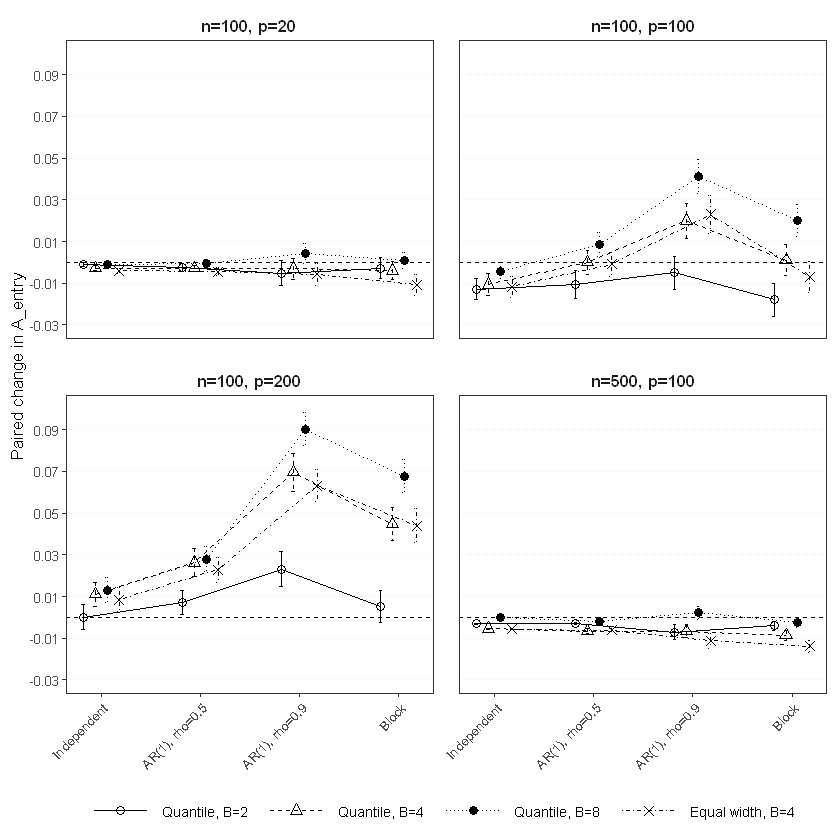

In [1]:
# ============================================================
# Reconstruct Figure 11 from the saved Monte Carlo results
# All four panels use the SAME y-axis scale
# No simulation is rerun
# ============================================================

if (!requireNamespace("ggplot2", quietly = TRUE)) {
  stop("Package 'ggplot2' is required. Install it with install.packages('ggplot2').")
}

library(ggplot2)

# ------------------------------------------------------------
# 1. Locate the completed Monte Carlo summary file
# ------------------------------------------------------------

csv_name <- "paired_difference_summary_long.csv"

candidate_paths <- unique(c(
  csv_name,
  file.path("output", csv_name),
  file.path("outputs", csv_name),
  file.path("results", csv_name),
  file.path("simulation_output", csv_name),
  list.files(
    path = ".",
    pattern = "^paired_difference_summary_long\\.csv$",
    recursive = TRUE,
    full.names = TRUE
  )
))

candidate_paths <- candidate_paths[file.exists(candidate_paths)]

if (length(candidate_paths) == 0L) {
  stop(
    paste0(
      "Could not find ", csv_name, ".\n",
      "Place this cell in the project containing the completed ",
      "Monte Carlo output, or edit csv_path manually."
    )
  )
}

csv_path <- normalizePath(
  candidate_paths[1],
  winslash = "/",
  mustWork = TRUE
)

message("Reading saved Monte Carlo results from: ", csv_path)

results <- read.csv(
  csv_path,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

# ------------------------------------------------------------
# 2. Check the required columns
# ------------------------------------------------------------

required_columns <- c(
  "n",
  "p",
  "dimension",
  "correlation",
  "scheme",
  "metric",
  "replications",
  "mean",
  "ci_lower",
  "ci_upper"
)

missing_columns <- setdiff(required_columns, names(results))

if (length(missing_columns) > 0L) {
  stop(
    "The saved CSV is missing these columns: ",
    paste(missing_columns, collapse = ", ")
  )
}

# ------------------------------------------------------------
# 3. Select the metric used in Figure 11
# ------------------------------------------------------------

plot_data <- results[
  results$metric == "delta_mean_entry_tau",
  required_columns
]

if (nrow(plot_data) == 0L) {
  stop("No rows were found for metric = 'delta_mean_entry_tau'.")
}

# ------------------------------------------------------------
# 4. Set the panel, correlation, and scheme order
# ------------------------------------------------------------

dimension_levels <- c(
  "n=100, p=20",
  "n=100, p=100",
  "n=100, p=200",
  "n=500, p=100"
)

correlation_levels <- c(
  "independent",
  "ar1_rho_0.5",
  "ar1_rho_0.9",
  "block"
)

correlation_labels <- c(
  "Independent",
  "AR(1), rho=0.5",
  "AR(1), rho=0.9",
  "Block"
)

scheme_levels <- c(
  "quantile_2",
  "quantile_4",
  "quantile_8",
  "equal_width_4"
)

scheme_labels <- c(
  "Quantile, B=2",
  "Quantile, B=4",
  "Quantile, B=8",
  "Equal width, B=4"
)

plot_data$dimension <- factor(
  plot_data$dimension,
  levels = dimension_levels
)

plot_data$correlation <- factor(
  plot_data$correlation,
  levels = correlation_levels
)

plot_data$scheme <- factor(
  plot_data$scheme,
  levels = scheme_levels
)

plot_data <- plot_data[
  complete.cases(
    plot_data$dimension,
    plot_data$correlation,
    plot_data$scheme,
    plot_data$mean,
    plot_data$ci_lower,
    plot_data$ci_upper
  ),
]

expected_rows <- length(dimension_levels) *
  length(correlation_levels) *
  length(scheme_levels)

if (nrow(plot_data) != expected_rows) {
  warning(
    "Expected ", expected_rows,
    " plotted rows but found ", nrow(plot_data), "."
  )
}

# ------------------------------------------------------------
# 5. Slightly separate the four schemes at each x position
# ------------------------------------------------------------

scheme_offsets <- c(
  quantile_2    = -0.18,
  quantile_4    = -0.06,
  quantile_8    =  0.06,
  equal_width_4 =  0.18
)

plot_data$x_position <-
  as.numeric(plot_data$correlation) +
  unname(scheme_offsets[as.character(plot_data$scheme)])

# ------------------------------------------------------------
# 6. Calculate ONE common y-axis range from all four panels
#
# For the current completed results, this should resolve to
# approximately -0.02 to 0.10.
# ------------------------------------------------------------

raw_limits <- range(
  c(
    0,
    plot_data$ci_lower,
    plot_data$ci_upper
  ),
  na.rm = TRUE
)

shared_y_limits <- c(
  floor(raw_limits[1] * 100) / 100,
  ceiling(raw_limits[2] * 100) / 100
)

# Ensure that zero is always included
shared_y_limits[1] <- min(shared_y_limits[1], 0)
shared_y_limits[2] <- max(shared_y_limits[2], 0)

message(
  "Common y-axis limits: ",
  paste(shared_y_limits, collapse = " to ")
)

y_breaks <- seq(
  from = shared_y_limits[1],
  to = shared_y_limits[2],
  by = 0.02
)

# ------------------------------------------------------------
# 7. Construct the four-panel figure
# ------------------------------------------------------------

figure11 <- ggplot(
  plot_data,
  aes(
    x = x_position,
    y = mean,
    group = scheme,
    linetype = scheme,
    shape = scheme
  )
) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    linewidth = 0.35
  ) +
  geom_errorbar(
    aes(
      ymin = ci_lower,
      ymax = ci_upper
    ),
    width = 0.035,
    linewidth = 0.38
  ) +
  geom_line(
    linewidth = 0.48
  ) +
  geom_point(
    size = 2.1,
    stroke = 0.65
  ) +
  facet_wrap(
    ~ dimension,
    ncol = 2,
    scales = "fixed",
    drop = FALSE
  ) +
  scale_x_continuous(
    breaks = seq_along(correlation_levels),
    labels = correlation_labels,
    limits = c(0.65, 4.35),
    expand = expansion(mult = 0)
  ) +
  scale_y_continuous(
    breaks = y_breaks
  ) +
  coord_cartesian(
    ylim = shared_y_limits
  ) +
  scale_linetype_manual(
    values = c(
      quantile_2    = "solid",
      quantile_4    = "dashed",
      quantile_8    = "dotted",
      equal_width_4 = "dotdash"
    ),
    breaks = scheme_levels,
    labels = scheme_labels,
    drop = FALSE
  ) +
  scale_shape_manual(
    values = c(
      quantile_2    = 1,
      quantile_4    = 2,
      quantile_8    = 16,
      equal_width_4 = 4
    ),
    breaks = scheme_levels,
    labels = scheme_labels,
    drop = FALSE
  ) +
  labs(
    x = NULL,
    y = "Paired change in A_entry",
    linetype = NULL,
    shape = NULL
  ) +
  guides(
    linetype = guide_legend(
      nrow = 1,
      byrow = TRUE
    ),
    shape = guide_legend(
      nrow = 1,
      byrow = TRUE
    )
  ) +
  theme_bw(base_size = 10) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(
      linewidth = 0.25,
      linetype = "dotted"
    ),
    strip.background = element_blank(),
    strip.text = element_text(
      face = "bold",
      size = 10
    ),
    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      vjust = 1,
      size = 8
    ),
    axis.text.y = element_text(size = 8),
    axis.title.y = element_text(size = 10),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.key.width = grid::unit(1.4, "cm"),
    legend.text = element_text(size = 8.5),
    panel.spacing = grid::unit(1.1, "lines"),
    plot.margin = margin(
      t = 6,
      r = 8,
      b = 4,
      l = 6
    )
  )

# ------------------------------------------------------------
# 8. Save the replacement figure
#
# The files are saved beside the completed summary CSV.
# The PDF filename matches the filename used in the TeX paper.
# ------------------------------------------------------------

output_directory <- dirname(csv_path)

pdf_file <- file.path(
  output_directory,
  "delta_entry_order_agreement.pdf"
)

png_file <- file.path(
  output_directory,
  "delta_entry_order_agreement.png"
)

ggsave(
  filename = pdf_file,
  plot = figure11,
  width = 9,
  height = 6.4,
  units = "in",
  device = "pdf"
)

ggsave(
  filename = png_file,
  plot = figure11,
  width = 9,
  height = 6.4,
  units = "in",
  dpi = 600,
  bg = "white"
)

print(figure11)

message("Saved PDF: ", normalizePath(pdf_file, winslash = "/"))
message("Saved PNG: ", normalizePath(png_file, winslash = "/"))